#  <center> Speech Emotion Recognition <center>

#### Datasets used in this project

* Crowd-sourced Emotional Mutimodal Actors Dataset (Crema-D)
https://www.kaggle.com/datasets/ejlok1/cremad
* Ryerson Audio-Visual Database of Emotional Speech and Song (Ravdess)
https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
* Surrey Audio-Visual Expressed Emotion (Savee)
http://kaggle.com/datasets/ejlok1/surrey-audiovisual-expressed-emotion-savee
* Toronto emotional speech set (Tess)
https://www.kaggle.com/datasets/ejlok1/toronto-emotional-speech-set-tess

# Importing Libraries

In [1]:
import sys
print(sys.version)

3.9.18 (main, Sep 11 2023, 13:30:38) [MSC v.1916 64 bit (AMD64)]


In [ ]:
import pandas as pd
import numpy as np

import os
import sys

# librosa is a Python library for analyzing audio and music. It can be used to extract the data from the audio files we will see it later.
import librosa
import librosa.display
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# to play the audio files
from IPython.display import Audio

import keras
from keras.callbacks import ReduceLROnPlateau
from keras.models import Sequential
from keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import np_utils
from tensorflow.keras.utils import to_categorical

#to_categorical
from keras.callbacks import ModelCheckpoint

import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning) 

## Data Preparation
* As we are working with four different datasets, so i will be creating a dataframe storing all emotions of the data in dataframe with their paths.
* We will use this dataframe to extract features for our model training.

In [3]:
# Paths for data.
Ravdess = "/lenovo-ideapad/CUDA_PJT/DATASET/second/"
Crema = "/lenovo-ideapad/CUDA_PJT/DATASET/AudioWAV/"
Tess = "/lenovo-ideapad/CUDA_PJT/DATASET/TESS/"
Savee = "/lenovo-ideapad/CUDA_PJT/DATASET/ALL/"

##  <center> 1. Ravdess Dataframe <center>
Here is the filename identifiers as per the official RAVDESS website:

* Modality (01 = full-AV, 02 = video-only, 03 = audio-only).
* Vocal channel (01 = speech, 02 = song).
* Emotion (01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised).
* Emotional intensity (01 = normal, 02 = strong). NOTE: There is no strong intensity for the 'neutral' emotion.
* Statement (01 = "Kids are talking by the door", 02 = "Dogs are sitting by the door").
* Repetition (01 = 1st repetition, 02 = 2nd repetition).
* Actor (01 to 24. Odd numbered actors are male, even numbered actors are female).

So, here's an example of an audio filename. 02-01-06-01-02-01-12.mp4
This means the meta data for the audio file is:

* Video-only (02)
* Speech (01)
* Fearful (06)
* Normal intensity (01)
* Statement "dogs" (02)
* 1st Repetition (01)
* 12th Actor (12) - Female (as the actor ID number is even)

In [4]:
ravdess_directory_list = os.listdir(Ravdess)

file_emotion = []
file_path = []
for dir in ravdess_directory_list:
    # as their are 20 different actors in our previous directory we need to extract files for each actor.
    actor = os.listdir(Ravdess + dir)
    for file in actor:
        part = file.split('.')[0]
        part = part.split('-')
        # third part in each file represents the emotion associated to that file.
        file_emotion.append(int(part[2]))
        file_path.append(Ravdess + dir + '/' + file)
        
# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
Ravdess_df = pd.concat([emotion_df, path_df], axis=1)

# changing integers to actual emotions.
Ravdess_df.Emotions.replace({1:'neutral', 2:'calm', 3:'happy', 4:'sad', 5:'angry', 6:'fear', 7:'disgust', 8:'surprise'}, inplace=True)
Ravdess_df.head()

,Emotions,Path
0,neutral,/lenovo-ideapad/CUDA_PJT/DATASET/second/Actor_...
1,neutral,/lenovo-ideapad/CUDA_PJT/DATASET/second/Actor_...
2,neutral,/lenovo-ideapad/CUDA_PJT/DATASET/second/Actor_...
3,neutral,/lenovo-ideapad/CUDA_PJT/DATASET/second/Actor_...
4,calm,/lenovo-ideapad/CUDA_PJT/DATASET/second/Actor_...


## <center>2. Crema DataFrame</center>

In [5]:
crema_directory_list = os.listdir(Crema)

file_emotion = []
file_path = []

for file in crema_directory_list:
    # storing file paths
    file_path.append(Crema + file)
    # storing file emotions
    part=file.split('_')
    if part[2] == 'SAD':
        file_emotion.append('sad')
    elif part[2] == 'ANG':
        file_emotion.append('angry')
    elif part[2] == 'DIS':
        file_emotion.append('disgust')
    elif part[2] == 'FEA':
        file_emotion.append('fear')
    elif part[2] == 'HAP':
        file_emotion.append('happy')
    elif part[2] == 'NEU':
        file_emotion.append('neutral')
    else:
        file_emotion.append('Unknown')
        
# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
Crema_df = pd.concat([emotion_df, path_df], axis=1)
Crema_df.head()

,Emotions,Path
0,angry,/lenovo-ideapad/CUDA_PJT/DATASET/AudioWAV/1001...
1,disgust,/lenovo-ideapad/CUDA_PJT/DATASET/AudioWAV/1001...
2,fear,/lenovo-ideapad/CUDA_PJT/DATASET/AudioWAV/1001...
3,happy,/lenovo-ideapad/CUDA_PJT/DATASET/AudioWAV/1001...
4,neutral,/lenovo-ideapad/CUDA_PJT/DATASET/AudioWAV/1001...


##  <center> 3. TESS dataset <center>

In [6]:
tess_directory_list = os.listdir(Tess)
# print(tess_directory_list)
file_emotion = []
file_path = []

for dir in tess_directory_list:
    directories = os.listdir(Tess + dir)
    # print(directories)
    for file in directories:
        part = file.split('.')[0]
        part = part.split('_')[2]
        if part=='ps':
            file_emotion.append('surprise')
        else:
            file_emotion.append(part)
        file_path.append(Tess + dir + '/' + file)
        
# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
Tess_df = pd.concat([emotion_df, path_df], axis=1)
Tess_df.head()

,Emotions,Path
0,angry,/lenovo-ideapad/CUDA_PJT/DATASET/TESS/OAF_angr...
1,angry,/lenovo-ideapad/CUDA_PJT/DATASET/TESS/OAF_angr...
2,angry,/lenovo-ideapad/CUDA_PJT/DATASET/TESS/OAF_angr...
3,angry,/lenovo-ideapad/CUDA_PJT/DATASET/TESS/OAF_angr...
4,angry,/lenovo-ideapad/CUDA_PJT/DATASET/TESS/OAF_angr...


##  <center> 4. CREMA-D dataset <center>
The audio files in this dataset are named in such a way that the prefix letters describes the emotion classes as follows:

* 'a' = 'anger'
* 'd' = 'disgust'
* 'f' = 'fear'
* 'h' = 'happiness'
* 'n' = 'neutral'
* 'sa' = 'sadness'
* 'su' = 'surprise'

In [7]:
savee_directory_list = os.listdir(Savee)

file_emotion = []
file_path = []

for file in savee_directory_list:
    file_path.append(Savee + file)
    part = file.split('_')[1]
    ele = part[:-6]
    if ele=='a':
        file_emotion.append('angry')
    elif ele=='d':
        file_emotion.append('disgust')
    elif ele=='f':
        file_emotion.append('fear')
    elif ele=='h':
        file_emotion.append('happy')
    elif ele=='n':
        file_emotion.append('neutral')
    elif ele=='sa':
        file_emotion.append('sad')
    else:
        file_emotion.append('surprise')
        
# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
Savee_df = pd.concat([emotion_df, path_df], axis=1)
Savee_df.head()

,Emotions,Path
0,angry,/lenovo-ideapad/CUDA_PJT/DATASET/ALL/DC_a01.wav
1,angry,/lenovo-ideapad/CUDA_PJT/DATASET/ALL/DC_a02.wav
2,angry,/lenovo-ideapad/CUDA_PJT/DATASET/ALL/DC_a03.wav
3,angry,/lenovo-ideapad/CUDA_PJT/DATASET/ALL/DC_a04.wav
4,angry,/lenovo-ideapad/CUDA_PJT/DATASET/ALL/DC_a05.wav


In [8]:
# creating Dataframe using all the 4 dataframes we created so far.
data_path = pd.concat([Ravdess_df, Crema_df, Tess_df, Savee_df], axis = 0)
data_path.to_csv("data_path.csv",index=False)
data_path.head()

,Emotions,Path
0,neutral,/lenovo-ideapad/CUDA_PJT/DATASET/second/Actor_...
1,neutral,/lenovo-ideapad/CUDA_PJT/DATASET/second/Actor_...
2,neutral,/lenovo-ideapad/CUDA_PJT/DATASET/second/Actor_...
3,neutral,/lenovo-ideapad/CUDA_PJT/DATASET/second/Actor_...
4,calm,/lenovo-ideapad/CUDA_PJT/DATASET/second/Actor_...


## Data Visualisation and Exploration

First let's plot the count of each emotions in our dataset.

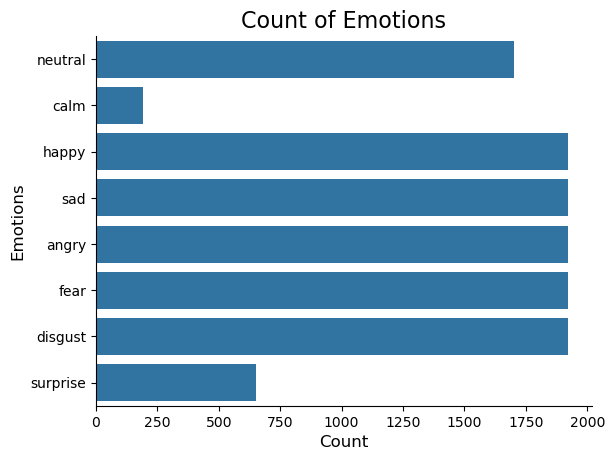

In [9]:
plt.title('Count of Emotions', size=16)
sns.countplot(data_path.Emotions)
plt.ylabel('Emotions', size=12)
plt.xlabel('Count', size=12)
sns.despine(top=True, right=True, left=False, bottom=False)
plt.show()

## Data Augmentation

- Data augmentation is the process by which we create new synthetic data samples by adding small perturbations on our initial training set.
- To generate syntactic data for audio, we can apply noise injection, shifting time, changing pitch and speed.
- The objective is to make our model invariant to those perturbations and enhace its ability to generalize.
- In order to this to work adding the perturbations must conserve the same label as the original training sample.
- In images data augmention can be performed by shifting the image, zooming, rotating ...

First, let's check which augmentation techniques works better for our dataset.

In [15]:
def noise(data):
    noise_amp = 0.035*np.random.uniform()*np.amax(data)
    data = data + noise_amp*np.random.normal(size=data.shape[0])
    return data

def stretch(data):
    return librosa.effects.time_stretch(data, rate=0.8)

def shift(data):
    shift_range = int(np.random.uniform(low=-5, high = 5)*1000)
    return np.roll(data, shift_range)

def pitch(data, sampling_rate):
    return librosa.effects.pitch_shift(data, sr = sampling_rate, n_steps=0.7)

# taking any example and checking for techniques.
path = np.array(data_path.Path)[1]
data, sample_rate = librosa.load(path, sr=16000)


#### 1. Simple Audio

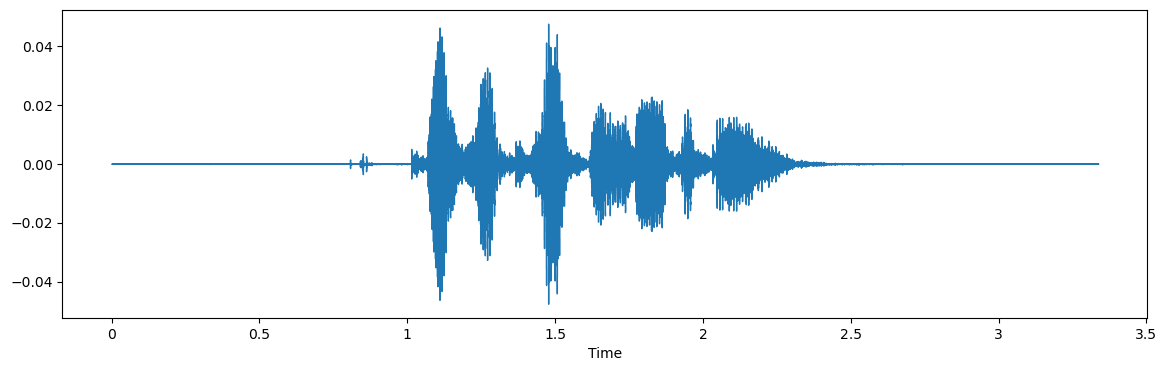

In [17]:
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=data, sr=sample_rate)
Audio(path)

#### 2. Noise Injection

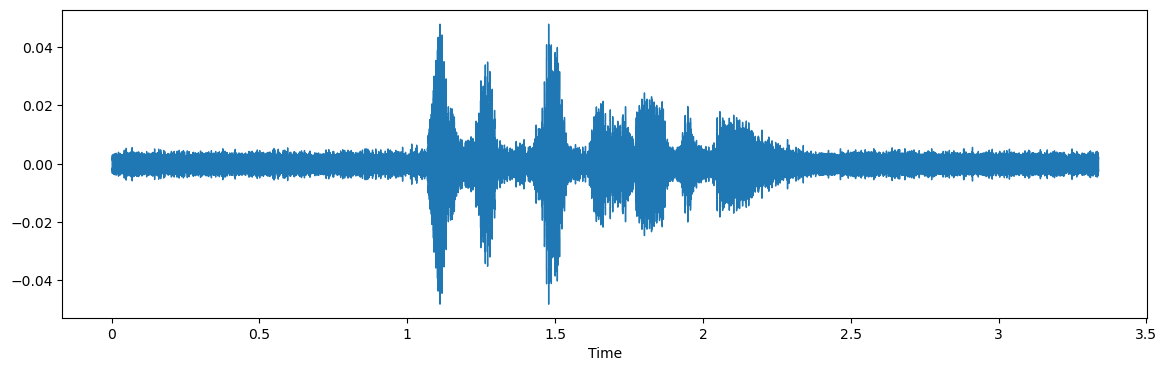

In [18]:
x = noise(data)
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
Audio(x, rate=sample_rate)

We can see noise injection is a very good augmentation technique because of which we can assure our training model is not overfitted

#### 3. Stretching

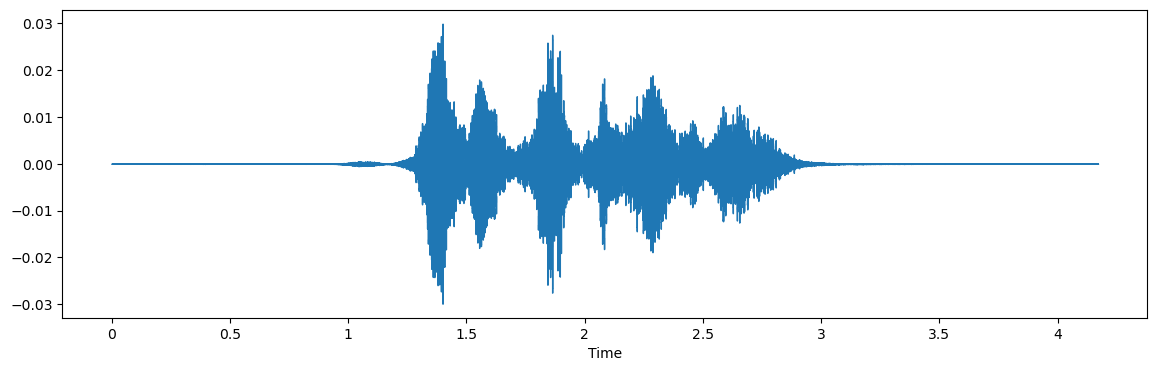

In [19]:
x = stretch(data)
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
Audio(x, rate=sample_rate)

#### 4. Shifting

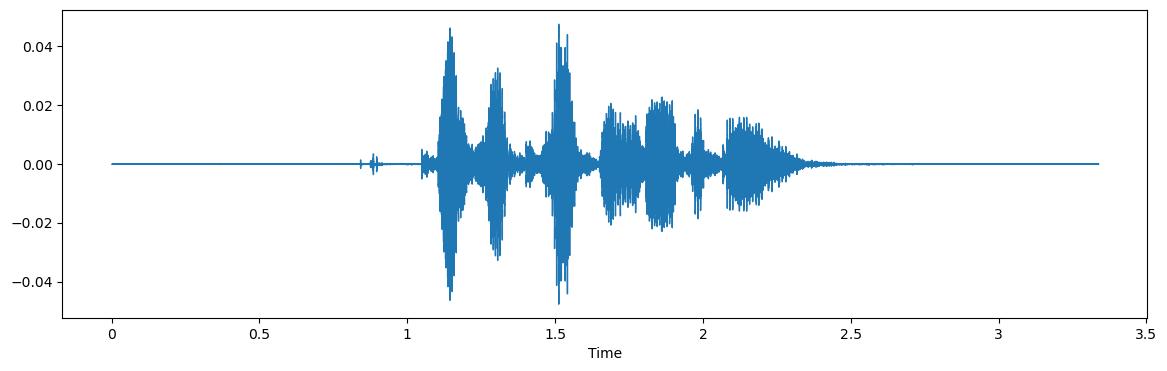

In [20]:
x = shift(data)
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
Audio(x, rate=sample_rate)

#### 5. Pitch

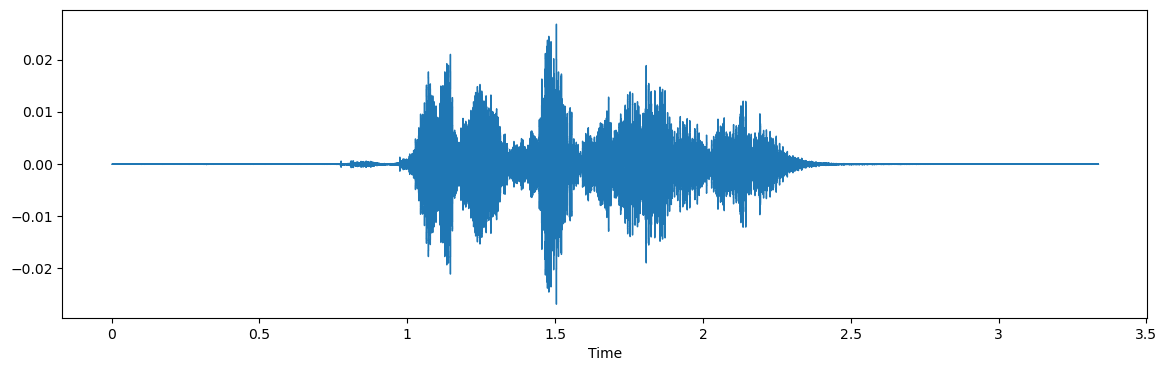

In [21]:
x = pitch(data, sample_rate)
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
Audio(x, rate=sample_rate)

- From the above types of augmentation techniques i am using noise, stretching(ie. changing speed) and some pitching.

## Feature Extraction
- Extraction of features is a very important part in analyzing and finding relations between different things. As we already know that the data provided of audio cannot be understood by the models directly so we need to convert them into an understandable format for which feature extraction is used.


The audio signal is a three-dimensional signal in which three axes represent time, amplitude and frequency.

![image.png](https://miro.medium.com/max/633/1*7sKM9aECRmuoqTadCYVw9A.jpeg)

I am no expert on audio signals and feature extraction on audio files so i need to search and found a very good blog written by [Askash Mallik](https://medium.com/heuristics/audio-signal-feature-extraction-and-clustering-935319d2225) on feature extraction.

As stated there with the help of the sample rate and the sample data, one can perform several transformations on it to extract valuable features out of it.
1. Zero Crossing Rate : The rate of sign-changes of the signal during the duration of a particular frame.
2. Energy : The sum of squares of the signal values, normalized by the respective frame length.
3. Entropy of Energy : The entropy of sub-frames’ normalized energies. It can be interpreted as a measure of abrupt changes.
4. Spectral Centroid : The center of gravity of the spectrum.
5. Spectral Spread : The second central moment of the spectrum.
6. Spectral Entropy :  Entropy of the normalized spectral energies for a set of sub-frames.
7. Spectral Flux : The squared difference between the normalized magnitudes of the spectra of the two successive frames.
8. Spectral Rolloff : The frequency below which 90% of the magnitude distribution of the spectrum is concentrated.
9.  MFCCs Mel Frequency Cepstral Coefficients form a cepstral representation where the frequency bands are not linear but distributed according to the mel-scale.
10. Chroma Vector : A 12-element representation of the spectral energy where the bins represent the 12 equal-tempered pitch classes of western-type music (semitone spacing).
11. Chroma Deviation : The standard deviation of the 12 chroma coefficients.


In this project i am not going deep in feature selection process to check which features are good for our dataset rather i am only extracting 5 features:
- Zero Crossing Rate
- Chroma_stft
- MFCC
- RMS(root mean square) value
- MelSpectogram to train our model.

What i've found is pretty good:
- Chroma_stft (short time fourier transform)
- chroma_cqt (constant q transform) = bettr for longer speech, good for calm, anger or sad expressions NOT GOOD FOR NOW 
- chroma_cens (chroma energy normalized) = not relevent
- chroma_vqt (variable q transform) = again not relevent both are good in capturing harmonic content. NOT IN REGULAR SPEECH
- melspectrogram = mimics human auditory perception
- MFCC
- RMS
- spectral_centroid
- spectral_bandwidth
- spectral_contrast = can try. distinguishes the sharpeness and smoothness of a voice.
- spectral_flatness
- spectral_rolloff
- zero_crossing_rate

In [ ]:
def extract_features(data):
    # ZCR
    result = np.array([])
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=data).T, axis=0)
    result=np.hstack((result, zcr)) # stacking horizontally

    # Chroma_stft
    stft = np.abs(librosa.stft(data))
    chroma_stft = np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate).T, axis=0)
    result = np.hstack((result, chroma_stft)) # stacking horizontally

    # MFCC
    mfcc = np.mean(librosa.feature.mfcc(y=data, sr=sample_rate).T, axis=0)
    result = np.hstack((result, mfcc)) # stacking horizontally

    # Root Mean Square Value
    rms = np.mean(librosa.feature.rms(y=data).T, axis=0)
    result = np.hstack((result, rms)) # stacking horizontally

    # MelSpectogram
    mel = np.mean(librosa.feature.melspectrogram(y=data, sr=sample_rate).T, axis=0)
    result = np.hstack((result, mel)) # stacking horizontally
    
    return result

def get_features(path):
    # duration and offset are used to take care of the no audio in start and the ending of each audio files as seen above.
    data, sample_rate = librosa.load(path, sr=16000,duration=2.5, offset=0.6)
    
    # without augmentation
    res1 = extract_features(data)
    result = np.array(res1)
    
    # data with noise
    noise_data = noise(data)
    res2 = extract_features(noise_data)
    result = np.vstack((result, res2)) # stacking vertically
    
    # data with stretching and pitching
    new_data = stretch(data)
    data_stretch_pitch = pitch(new_data, sample_rate)
    res3 = extract_features(data_stretch_pitch)
    result = np.vstack((result, res3)) # stacking vertically
    
    return result

In [27]:
X, Y = [], []
for path, emotion in zip(data_path.Path, data_path.Emotions):
    feature = get_features(path)
    for ele in feature:
        X.append(ele)
        # appending emotion 3 times as we have made 3 augmentation techniques on each audio file.
        Y.append(emotion)

In [28]:
len(X), len(Y), data_path.Path.shape

(36486, 36486, (12162,))

In [ ]:
Features = pd.DataFrame(X)
Features['labels'] = Y
# Creates a csv file of the features extracted in the same folder, so you can just use this later for the training part
Features.to_csv('NEWfeatures.csv', index=False)
Features.head()

,0,1,2,3,4,5,6,7,8,9,...,150,151,152,153,154,155,156,157,158,labels
0,0.321275,-645.880737,72.619637,0.841305,16.399446,10.241591,0.653901,-4.328002,-4.258932,-14.575824,...,0.713529,0.660531,0.684966,0.733049,0.753972,0.736093,0.717020,0.668645,0.002988,neutral
1,0.317089,-447.374585,31.327410,8.998368,9.350276,5.319127,-0.821865,-3.628963,-6.894159,-8.861799,...,0.794809,0.682216,0.684445,0.738635,0.776799,0.767612,0.752653,0.742245,0.003402,neutral
2,0.188285,-712.553894,70.982239,-0.730641,16.815950,7.990960,-0.822255,-6.391049,-6.146890,-15.975554,...,0.701736,0.682363,0.662836,0.686489,0.733964,0.755725,0.745676,0.684084,0.001476,neutral
3,0.293566,-634.663269,72.324066,-2.998578,20.209740,10.674218,-1.151011,-2.813592,-7.923956,-16.231958,...,0.680533,0.675352,0.628977,0.679179,0.707283,0.734498,0.724930,0.702075,0.003226,neutral
4,0.319404,-426.393898,26.511167,8.757837,10.239777,5.180530,-0.626000,-2.140771,-6.637968,-8.595380,...,0.784828,0.765226,0.662272,0.688544,0.728716,0.768479,0.785350,0.775771,0.003791,neutral


In [ ]:
# Only run this if you are running an already acquired Features.csv file
Features = pd.read_csv("--") # Fill -- with the csv file path
Features.head()


,0,1,2,3,4,5,6,7,8,9,...,153,154,155,156,157,158,159,160,161,labels
0,0.131492,0.586942,0.561041,0.526812,0.564523,0.583762,0.613125,0.706722,0.649077,0.657037,...,0.000918,0.001432,0.001464,0.000142,0.000065,0.000046,0.000024,0.000013,7.116983e-07,neutral
1,0.321497,0.700739,0.701270,0.674776,0.699298,0.711850,0.650549,0.715831,0.673765,0.680029,...,0.001020,0.001583,0.001594,0.000252,0.000188,0.000184,0.000154,0.000154,1.381913e-04,neutral
2,0.100029,0.581267,0.591644,0.564283,0.497159,0.521353,0.529365,0.567357,0.690129,0.645830,...,0.000003,0.000073,0.000179,0.000354,0.000154,0.000015,0.000010,0.000004,2.038588e-07,neutral
3,0.117952,0.595483,0.593569,0.572277,0.595233,0.562348,0.526804,0.535419,0.576417,0.651526,...,0.000210,0.000246,0.000492,0.000427,0.000911,0.001377,0.000718,0.000534,4.850388e-05,angry
4,0.288511,0.698188,0.699725,0.709917,0.718245,0.682861,0.578561,0.577790,0.618633,0.699169,...,0.001036,0.001034,0.001256,0.001226,0.001648,0.002112,0.001553,0.001411,9.104754e-04,angry


* We have applied data augmentation and extracted the features for each audio files and saved them.

## Data Preparation

- As of now we have extracted the data, now we need to normalize and split our data for training and testing.

In [ ]:
#### DATA PREP ###########
def extract_mfcc(file_path, sr=16000, max_duration=4, n_mfcc=40):
    signal, _ = librosa.load(file_path, sr=sr)

    max_len = int(sr * max_duration)
    if len(signal) > max_len:
        signal = signal[:max_len]
    else:
        signal = np.pad(signal, (0, max_len - len(signal)), mode='constant')

    # Extract MFCCs
    mfcc = librosa.feature.mfcc(signal, sr=sr, n_mfcc=n_mfcc)
    mfcc = mfcc.T  # Shape: (time_steps, n_mfcc)

    # Normalize
    mfcc = (mfcc - np.mean(mfcc)) / np.std(mfcc)

    return mfcc  # Final shape: (time_steps, n_mfcc)


In [30]:
X = Features.iloc[: ,:-1].values
Y = Features['labels'].values

In [31]:
# As this is a multiclass classification problem onehotencoding our Y.
encoder = OneHotEncoder()
Y = encoder.fit_transform(np.array(Y).reshape(-1,1)).toarray()

In [32]:
# splitting data
x_train, x_test, y_train, y_test = train_test_split(X, Y, random_state=0, shuffle=True)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((27364, 159), (27364, 8), (9122, 159), (9122, 8))

In [33]:
# scaling our data with sklearn's Standard scaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((27364, 159), (27364, 8), (9122, 159), (9122, 8))

In [34]:
# making our data compatible to model.
x_train = np.expand_dims(x_train, axis=2)
x_test = np.expand_dims(x_test, axis=2)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((27364, 159, 1), (27364, 8), (9122, 159, 1), (9122, 8))

## Modelling CNN

In [35]:
model=Sequential()
model.add(Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu', input_shape=(x_train.shape[1], 1)))
model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))

model.add(Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu'))
model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))

model.add(Conv1D(128, kernel_size=5, strides=1, padding='same', activation='relu'))
model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))
model.add(Dropout(0.2))

model.add(Conv1D(64, kernel_size=5, strides=1, padding='same', activation='relu'))
model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))

model.add(Flatten())
model.add(Dense(units=32, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(units=8, activation='softmax'))
model.compile(optimizer = 'adam' , loss = 'categorical_crossentropy' , metrics = ['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 159, 256)          1536      
                                                                 
 max_pooling1d (MaxPooling1D  (None, 80, 256)          0         
 )                                                               
                                                                 
 conv1d_1 (Conv1D)           (None, 80, 256)           327936    
                                                                 
 max_pooling1d_1 (MaxPooling  (None, 40, 256)          0         
 1D)                                                             
                                                                 
 conv1d_2 (Conv1D)           (None, 40, 128)           163968    
                                                                 
 max_pooling1d_2 (MaxPooling  (None, 20, 128)          0

In [36]:
rlrp = ReduceLROnPlateau(monitor='loss', factor=0.4, verbose=0, patience=2, min_lr=0.0000001)
history=model.fit(x_train, y_train, batch_size=64, epochs=50, validation_data=(x_test, y_test), callbacks=[rlrp])
model.save('trained_model.h5')

Epoch 1/50
428/428 [==============================] - 20s 46ms/step - loss: 1.6848 - accuracy: 0.3261 - val_loss: 1.4523 - val_accuracy: 0.4239 - lr: 0.0010
Epoch 2/50
428/428 [==============================] - 20s 47ms/step - loss: 1.4834 - accuracy: 0.4056 - val_loss: 1.3950 - val_accuracy: 0.4577 - lr: 0.0010
Epoch 3/50
428/428 [==============================] - 19s 43ms/step - loss: 1.3862 - accuracy: 0.4481 - val_loss: 1.2720 - val_accuracy: 0.4884 - lr: 0.0010
Epoch 4/50
428/428 [==============================] - 22s 51ms/step - loss: 1.3306 - accuracy: 0.4699 - val_loss: 1.2570 - val_accuracy: 0.5008 - lr: 0.0010
Epoch 5/50
428/428 [==============================] - 21s 49ms/step - loss: 1.2908 - accuracy: 0.4868 - val_loss: 1.2249 - val_accuracy: 0.5159 - lr: 0.0010
Epoch 6/50
428/428 [==============================] - 22s 50ms/step - loss: 1.2532 - accuracy: 0.5003 - val_loss: 1.1912 - val_accuracy: 0.5260 - lr: 0.0010
Epoch 7/50
428/428 [==============================] - 21s 

## MODELLING LSTM

In [41]:
model = Sequential()

# LSTM layer (you can stack more if you want deeper memory)
model.add(LSTM(128, return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])))
model.add(Dropout(0.3))

# Another LSTM layer (optional)
model.add(LSTM(64))
model.add(Dropout(0.3))

# Fully connected layers
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

# Output layer
model.add(Dense(8, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 159, 128)          66560     
                                                                 
 dropout_2 (Dropout)         (None, 159, 128)          0         
                                                                 
 lstm_1 (LSTM)               (None, 64)                49408     
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dropout_4 (Dropout)         (None, 32)                0         
                                                                 
 dense_3 (Dense)             (None, 8)                

In [42]:
rlrp = ReduceLROnPlateau(monitor='val_loss', factor=0.4, verbose=0, patience=2, min_lr=0.0000001)
history=model.fit(x_train, y_train, batch_size=128, epochs=100, validation_data=(x_test, y_test), callbacks=[rlrp])
model.save('LSTM_trained_model.h5')

Epoch 1/100
214/214 [==============================] - 56s 250ms/step - loss: 1.8448 - accuracy: 0.2560 - val_loss: 1.7011 - val_accuracy: 0.3282 - lr: 0.0010
Epoch 2/100
214/214 [==============================] - 57s 267ms/step - loss: 1.6873 - accuracy: 0.3243 - val_loss: 1.6390 - val_accuracy: 0.3484 - lr: 0.0010
Epoch 3/100
214/214 [==============================] - 57s 264ms/step - loss: 1.5736 - accuracy: 0.3717 - val_loss: 1.5001 - val_accuracy: 0.3971 - lr: 0.0010
Epoch 5/100
214/214 [==============================] - 57s 264ms/step - loss: 1.5121 - accuracy: 0.3948 - val_loss: 1.4494 - val_accuracy: 0.4156 - lr: 0.0010
Epoch 6/100
214/214 [==============================] - 56s 261ms/step - loss: 1.4754 - accuracy: 0.4085 - val_loss: 1.4417 - val_accuracy: 0.4200 - lr: 0.0010
Epoch 7/100
214/214 [==============================] - 56s 260ms/step - loss: 1.4562 - accuracy: 0.4149 - val_loss: 1.3898 - val_accuracy: 0.4409 - lr: 0.0010
Epoch 8/100
214/214 [=========================

286/286 [==============================] - 17s 59ms/step - loss: 1.2315 - accuracy: 0.5109
Accuracy of our model on test data :  51.08528733253479 %


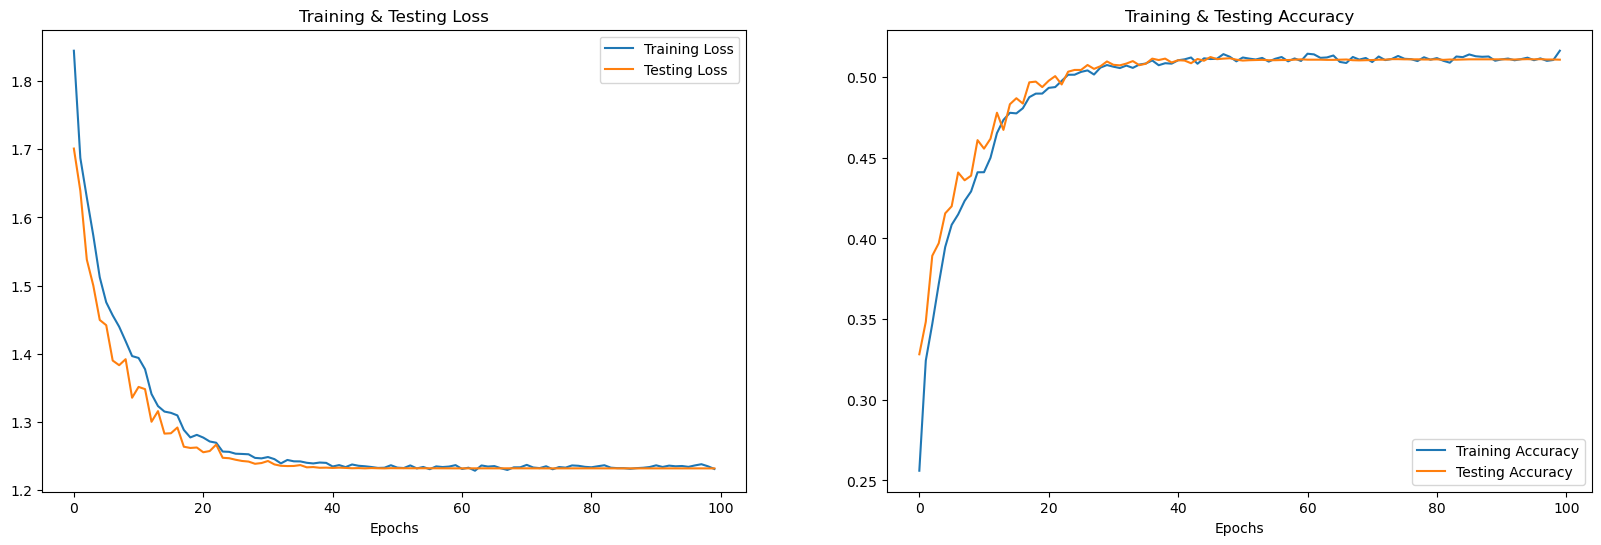

In [44]:
print("Accuracy of our model on test data : " , model.evaluate(x_test,y_test)[1]*100 , "%")

epochs = [i for i in range(100)]
fig , ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
test_acc = history.history['val_accuracy']
test_loss = history.history['val_loss']

fig.set_size_inches(20,6)
ax[0].plot(epochs , train_loss , label = 'Training Loss')
ax[0].plot(epochs , test_loss , label = 'Testing Loss')
ax[0].set_title('Training & Testing Loss')
ax[0].legend()
ax[0].set_xlabel("Epochs")

ax[1].plot(epochs , train_acc , label = 'Training Accuracy')
ax[1].plot(epochs , test_acc , label = 'Testing Accuracy')
ax[1].set_title('Training & Testing Accuracy')
ax[1].legend()
ax[1].set_xlabel("Epochs")
plt.show()

In [45]:
#####  CNN ############
print("Accuracy of our model on test data : " , model.evaluate(x_test,y_test)[1]*100 , "%")

epochs = [i for i in range(50)]
fig , ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
test_acc = history.history['val_accuracy']
test_loss = history.history['val_loss']

fig.set_size_inches(20,6)
ax[0].plot(epochs , train_loss , label = 'Training Loss')
ax[0].plot(epochs , test_loss , label = 'Testing Loss')
ax[0].set_title('Training & Testing Loss')
ax[0].legend()
ax[0].set_xlabel("Epochs")

ax[1].plot(epochs , train_acc , label = 'Training Accuracy')
ax[1].plot(epochs , test_acc , label = 'Testing Accuracy')
ax[1].set_title('Training & Testing Accuracy')
ax[1].legend()
ax[1].set_xlabel("Epochs")
plt.show()

 55/286 [====>.........................] - ETA: 14s - loss: 1.2164 - accuracy: 0.5091

KeyboardInterrupt: 

In [45]:
# predicting on test data.
pred_test = model.predict(x_test)
y_pred = encoder.inverse_transform(pred_test)

y_test = encoder.inverse_transform(y_test)

286/286 [==============================] - 3s 9ms/step


In [46]:
df = pd.DataFrame(columns=['Predicted Labels', 'Actual Labels'])
df['Predicted Labels'] = y_pred.flatten()
df['Actual Labels'] = y_test.flatten()

df.head(10)

,Predicted Labels,Actual Labels
0,sad,disgust
1,disgust,disgust
2,angry,angry
3,happy,disgust
4,fear,fear
5,sad,fear
6,happy,happy
7,happy,happy
8,disgust,sad
9,neutral,sad


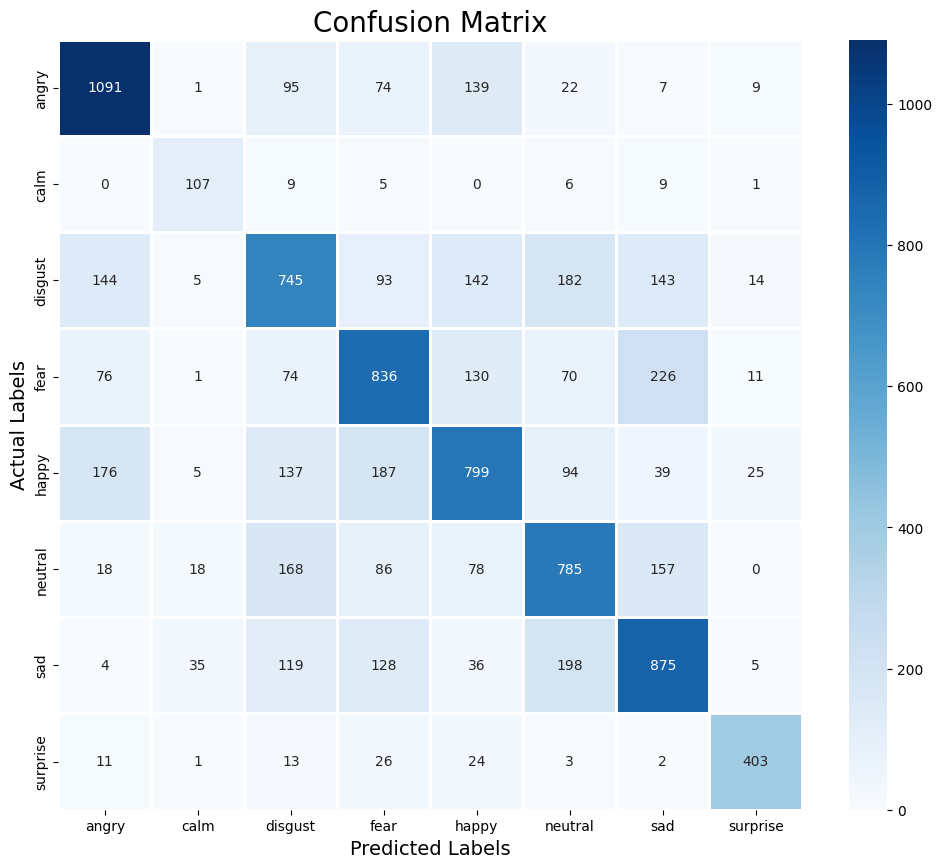

In [47]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (12, 10))
cm = pd.DataFrame(cm , index = [i for i in encoder.categories_] , columns = [i for i in encoder.categories_])
sns.heatmap(cm, linecolor='white', cmap='Blues', linewidth=1, annot=True, fmt='')
plt.title('Confusion Matrix', size=20)
plt.xlabel('Predicted Labels', size=14)
plt.ylabel('Actual Labels', size=14)
plt.show()

In [48]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       angry       0.72      0.76      0.74      1438
        calm       0.62      0.78      0.69       137
     disgust       0.55      0.51      0.53      1468
        fear       0.58      0.59      0.58      1424
       happy       0.59      0.55      0.57      1462
     neutral       0.58      0.60      0.59      1310
         sad       0.60      0.62      0.61      1400
    surprise       0.86      0.83      0.85       483

    accuracy                           0.62      9122
   macro avg       0.64      0.65      0.64      9122
weighted avg       0.62      0.62      0.62      9122



- We can see our model is more accurate in predicting surprise, angry emotions and it makes sense also because audio files of these emotions differ to other audio files in a lot of ways like pitch, speed etc..
- We overall achieved 61% accuracy on our test data and its decent but we can improve it more by applying more augmentation techniques and using other feature extraction methods.

# TRIAL AND ERROR


### MODELLING CNN-RNN Model


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from keras.models import Model
from keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization, concatenate, Flatten
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from keras.models import load_model
import librosa

# Load extracted features
data = pd.read_csv("./features.csv")
X = data.iloc[:, :-1].values
Y = data['labels'].values

# One-hot encode labels
encoder = OneHotEncoder()
Y = encoder.fit_transform(Y.reshape(-1, 1)).toarray()

# Split data
x_train, x_test, y_train, y_test = train_test_split(X, Y, random_state=0, shuffle=True)

# Scale features
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Expand dims for CNN/LSTM input
x_train = np.expand_dims(x_train, axis=2)
x_test = np.expand_dims(x_test, axis=2)

# Input layer
input_layer = Input(shape=(x_train.shape[1], 1))

# CNN path
cnn = Conv1D(16, kernel_size=256, strides=2, padding='same', activation='relu')(input_layer)
cnn = MaxPooling1D(pool_size=2, strides=2, padding='same')(cnn)
cnn = Conv1D(32, kernel_size=3, strides=2, padding='same', activation='relu')(cnn)
cnn = MaxPooling1D(pool_size=2, strides=2, padding='same')(cnn)
cnn = Conv1D(64, kernel_size=3, strides=2, padding='same', activation='relu')(cnn)
cnn = MaxPooling1D(pool_size=2, strides=2, padding='same')(cnn)
cnn = Conv1D(64, kernel_size=3, strides=2, padding='same', activation='relu')(cnn)
cnn = MaxPooling1D(pool_size=2, strides=2, padding='same')(cnn)
cnn = Conv1D(64, kernel_size=3, strides=2, padding='same', activation='relu')(cnn)
cnn = MaxPooling1D(pool_size=2, strides=2, padding='same')(cnn)
cnn = Flatten()(cnn)
cnn = Dense(100, activation='relu')(cnn)

# RNN path
rnn = Conv1D(16, kernel_size=256, strides=2, padding='same', activation='relu')(input_layer)
rnn = MaxPooling1D(pool_size=2, strides=2, padding='same')(rnn)
rnn = LSTM(128)(rnn)

# Concatenate CNN and RNN paths
merged = concatenate([cnn, rnn])
merged = Dense(64, activation='relu')(merged)
merged = Dropout(0.3)(merged)
output = Dense(8, activation='softmax')(merged)

# Compile model
model = Model(inputs=input_layer, outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Callbacks
rlrp = ReduceLROnPlateau(monitor='loss', factor=0.4, verbose=1, patience=2, min_lr=1e-7)
# early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model
history = model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=50,
    validation_data=(x_test, y_test),
    callbacks=[rlrp]
)

# Save model
model.save("hybrid_cnn_rnn_ser_model.h5")

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 162, 1)]     0           []                               
                                                                                                  
 conv1d (Conv1D)                (None, 81, 16)       4112        ['input_1[0][0]']                
                                                                                                  
 max_pooling1d (MaxPooling1D)   (None, 41, 16)       0           ['conv1d[0][0]']                 
                                                                                                  
 conv1d_1 (Conv1D)              (None, 21, 32)       1568        ['max_pooling1d[0][0]']          
                                                                                              

### Modelling CNN-BiLSTM Model

In [26]:
import numpy as np
import pandas as pd
import librosa
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, LSTM, concatenate
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Bidirectional

# Load preprocessed feature dataset
Features = pd.read_csv("features.csv")

# Separate features and labels
X = Features.iloc[:, :-1].values
Y = Features['labels'].values

# One hot encode labels
encoder = OneHotEncoder()
Y = encoder.fit_transform(np.array(Y).reshape(-1,1)).toarray()

# Split the dataset
x_train, x_test, y_train, y_test = train_test_split(X, Y, random_state=0, shuffle=True)

# Standardize features
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Expand dimensions for CNN/LSTM compatibility
x_train = np.expand_dims(x_train, axis=2)
x_test = np.expand_dims(x_test, axis=2)

# Define input shape
input_shape = (x_train.shape[1], 1)
input_layer = Input(shape=input_shape)

# CNN Path
cnn = Conv1D(256, kernel_size=7, strides=1, padding='same', activation='relu')(input_layer)
cnn = MaxPooling1D(pool_size=2, strides=2, padding='same')(cnn)
cnn = Conv1D(128, kernel_size=5, strides=1, padding='same', activation='relu')(cnn)
cnn = MaxPooling1D(pool_size=2, strides=2, padding='same')(cnn)
cnn = Conv1D(64, kernel_size=3, strides=1, padding='same', activation='relu')(cnn)
cnn = MaxPooling1D(pool_size=2, strides=2, padding='same')(cnn)
cnn = Flatten()(cnn)
cnn = Dense(64, activation='relu')(cnn)
cnn = Dropout(0.3)(cnn)

# LSTM Path
lstm = Bidirectional(LSTM(128, return_sequences=False))(input_layer)
lstm = Dense(64, activation='relu')(lstm)
lstm = Dropout(0.3)(lstm)

# Merge CNN and LSTM paths
merged = concatenate([cnn, lstm])
merged = Dense(64, activation='relu')(merged)
merged = Dropout(0.3)(merged)
output = Dense(8, activation='softmax')(merged)

# Create model
model = Model(inputs=input_layer, outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
rlrp = ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=2, min_lr=1e-7)
earlystop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model
history = model.fit(x_train, y_train, batch_size=128, epochs=50, validation_data=(x_test, y_test), callbacks=[rlrp,earlystop])

# Save model
model.save("hybrid_cnn_bi_lstm_ser_model.h5")


Epoch 1/50
428/428 [==============================] - 78s 174ms/step - loss: 1.5287 - accuracy: 0.3969 - val_loss: 1.2498 - val_accuracy: 0.5041 - lr: 0.0010
Epoch 2/50
428/428 [==============================] - 72s 169ms/step - loss: 1.2776 - accuracy: 0.5006 - val_loss: 1.1756 - val_accuracy: 0.5285 - lr: 0.0010
Epoch 3/50
428/428 [==============================] - 72s 169ms/step - loss: 1.0801 - accuracy: 0.5777 - val_loss: 1.0809 - val_accuracy: 0.5665 - lr: 0.0010
Epoch 6/50
428/428 [==============================] - 71s 165ms/step - loss: 1.0412 - accuracy: 0.5963 - val_loss: 1.0764 - val_accuracy: 0.5711 - lr: 0.0010
Epoch 7/50
428/428 [==============================] - 71s 166ms/step - loss: 1.0123 - accuracy: 0.6064 - val_loss: 1.0357 - val_accuracy: 0.5842 - lr: 0.0010
Epoch 8/50
428/428 [==============================] - 73s 171ms/step - loss: 0.9774 - accuracy: 0.6192 - val_loss: 0.9995 - val_accuracy: 0.6048 - lr: 0.0010
Epoch 9/50
428/428 [==============================] 

286/286 [==============================] - 9s 30ms/step - loss: 1.5297 - accuracy: 0.6774
Accuracy of our model on test data :  67.73734092712402 %


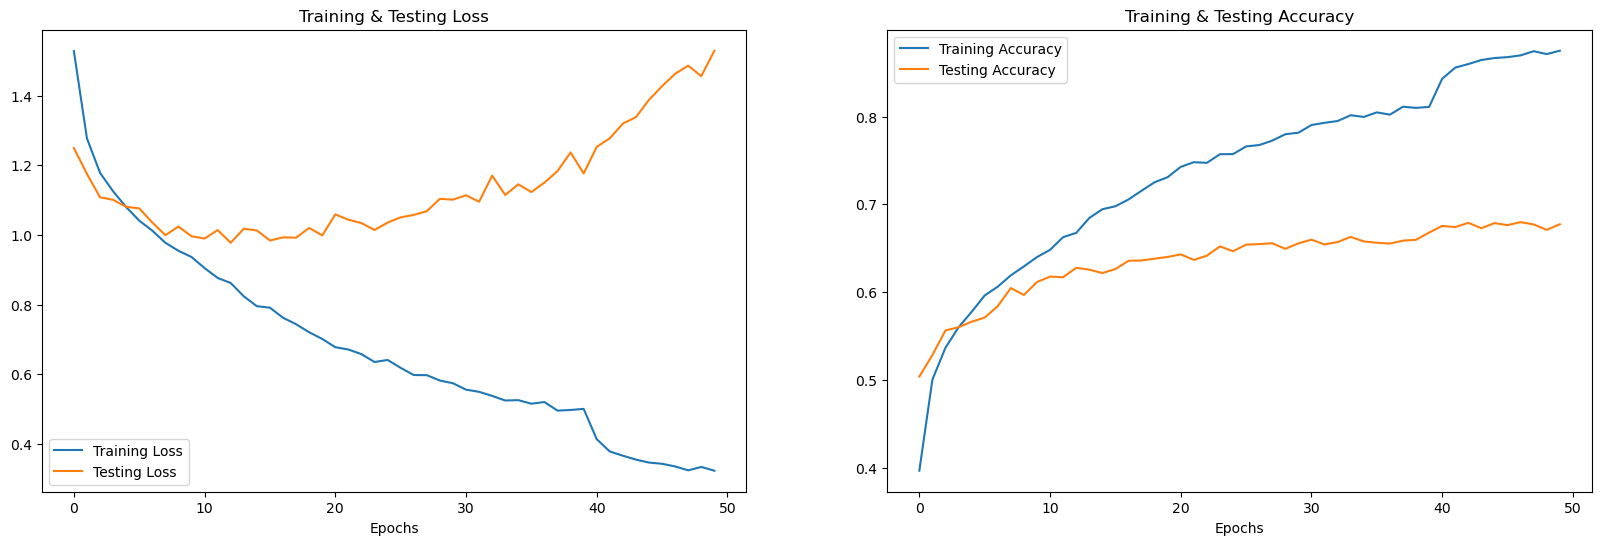

In [27]:
#####  CNN ############
print("Accuracy of our model on test data : " , model.evaluate(x_test,y_test)[1]*100 , "%")

epochs = [i for i in range(50)]
fig , ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
test_acc = history.history['val_accuracy']
test_loss = history.history['val_loss']

fig.set_size_inches(20,6)
ax[0].plot(epochs , train_loss , label = 'Training Loss')
ax[0].plot(epochs , test_loss , label = 'Testing Loss')
ax[0].set_title('Training & Testing Loss')
ax[0].legend()
ax[0].set_xlabel("Epochs")

ax[1].plot(epochs , train_acc , label = 'Training Accuracy')
ax[1].plot(epochs , test_acc , label = 'Testing Accuracy')
ax[1].set_title('Training & Testing Accuracy')
ax[1].legend()
ax[1].set_xlabel("Epochs")
plt.show()

<Axes: xlabel='labels', ylabel='count'>

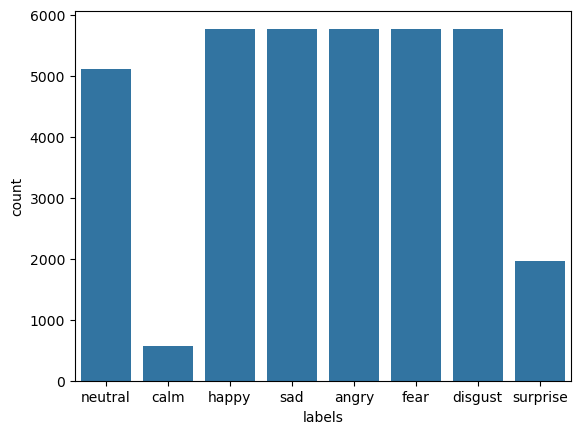

In [33]:
import seaborn as sns
sns.countplot(x=Features['labels'])



### Modelling CNN-Stacked BiLSTM Model

In [1]:
import numpy as np
import pandas as pd
import librosa
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, LSTM, concatenate
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Bidirectional

# Load preprocessed feature dataset
Features = pd.read_csv("features.csv")

# Separate features and labels
X = Features.iloc[:, :-1].values
Y = Features['labels'].values

# One hot encode labels
encoder = OneHotEncoder()
Y = encoder.fit_transform(np.array(Y).reshape(-1,1)).toarray()

# Split the dataset
x_train, x_test, y_train, y_test = train_test_split(X, Y, random_state=0, shuffle=True)

# Standardize features
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Expand dimensions for CNN/LSTM compatibility
x_train = np.expand_dims(x_train, axis=2)
x_test = np.expand_dims(x_test, axis=2)

# Define input shape
input_shape = (x_train.shape[1], 1)
input_layer = Input(shape=input_shape)

# CNN Path
cnn = Conv1D(256, kernel_size=7, strides=1, padding='same', activation='relu')(input_layer)
cnn = MaxPooling1D(pool_size=2, strides=2, padding='same')(cnn)
cnn = Conv1D(128, kernel_size=5, strides=1, padding='same', activation='relu')(cnn)
cnn = MaxPooling1D(pool_size=2, strides=2, padding='same')(cnn)
cnn = Conv1D(64, kernel_size=3, strides=1, padding='same', activation='relu')(cnn)
cnn = MaxPooling1D(pool_size=2, strides=2, padding='same')(cnn)
cnn = Flatten()(cnn)
cnn = Dense(64, activation='relu')(cnn)
cnn = Dropout(0.3)(cnn)

# Stacked LSTM Path
lstm = Bidirectional(LSTM(128, return_sequences=True))(input_layer)  # First LSTM layer returns sequences
lstm = Bidirectional(LSTM(128, return_sequences=False))(lstm)  # Second LSTM layer does not return sequences
lstm = Dense(64, activation='relu')(lstm)
lstm = Dropout(0.2)(lstm)

# Merge CNN and LSTM paths
merged = concatenate([cnn, lstm])
merged = Dense(64, activation='relu')(merged)
merged = Dropout(0.2)(merged)
output = Dense(8, activation='softmax')(merged)

# Create model
model = Model(inputs=input_layer, outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
rlrp = ReduceLROnPlateau(monitor='loss', factor=0.4, patience=2, min_lr=1e-7)
earlystop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model
history = model.fit(x_train, y_train, batch_size=128, epochs=50, validation_data=(x_test, y_test), callbacks=[rlrp, earlystop])

# Save model
model.save("hybrid_cnn_stacked_bi_lstm_ser_model.h5")


Epoch 1/50
214/214 [==============================] - 189s 839ms/step - loss: 1.5666 - accuracy: 0.3857 - val_loss: 1.2985 - val_accuracy: 0.4916 - lr: 0.0010
Epoch 2/50
214/214 [==============================] - 176s 822ms/step - loss: 1.2969 - accuracy: 0.4919 - val_loss: 1.1788 - val_accuracy: 0.5305 - lr: 0.0010
Epoch 3/50
214/214 [==============================] - 155s 724ms/step - loss: 1.1971 - accuracy: 0.5326 - val_loss: 1.1166 - val_accuracy: 0.5546 - lr: 0.0010
Epoch 4/50
214/214 [==============================] - 123s 576ms/step - loss: 1.1353 - accuracy: 0.5550 - val_loss: 1.0839 - val_accuracy: 0.5751 - lr: 0.0010
Epoch 5/50
214/214 [==============================] - 123s 577ms/step - loss: 1.0927 - accuracy: 0.5710 - val_loss: 1.0605 - val_accuracy: 0.5776 - lr: 0.0010
Epoch 6/50
214/214 [==============================] - 123s 576ms/step - loss: 1.0508 - accuracy: 0.5917 - val_loss: 1.0453 - val_accuracy: 0.5890 - lr: 0.0010
Epoch 7/50
214/214 [==========================